In [ ]:
import time
import random
import heapq
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import networkx as nx
import numpy as np


sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

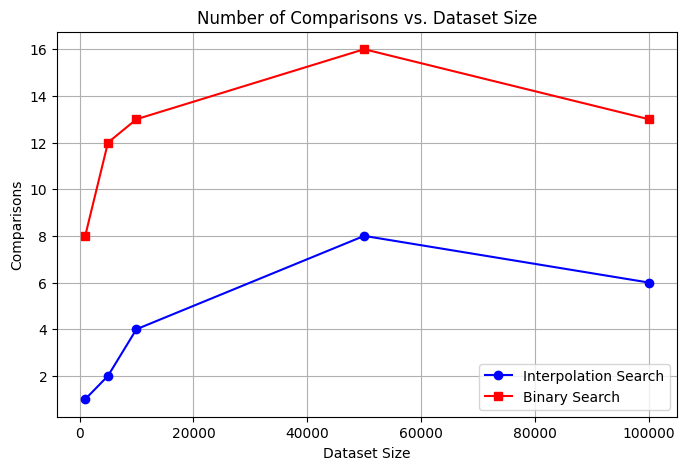

In [ ]:
import random
import time
import matplotlib.pyplot as plt

def interpolation_search(arr, target):
    low, high = 0, len(arr) - 1
    comparisons = 0
    while low <= high and arr[low] <= target <= arr[high]:
        comparisons += 1
        if low == high:
            return (low, comparisons) if arr[low] == target else (-1, comparisons)
        
        
        pos = low + int(((target - arr[low]) * (high - low)) / (arr[high] - arr[low]))
        
        if arr[pos] == target:
            return pos, comparisons
        elif arr[pos] < target:
            low = pos + 1
        else:
            high = pos - 1
    return -1, comparisons

def binary_search(arr, target):
    low, high = 0, len(arr) - 1
    comparisons = 0
    while low <= high:
        comparisons += 1
        mid = (low + high) // 2
        if arr[mid] == target:
            return mid, comparisons
        elif arr[mid] < target:
            low = mid + 1
        else:
            high = mid - 1
    return -1, comparisons


sizes = [1000, 5000, 10000, 50000, 100000]
is_comps, bs_comps = [], []

for size in sizes:
    arr = sorted(random.sample(range(size * 10), size))
    target = arr[random.randint(0, size - 1)]
    
    _, comp_is = interpolation_search(arr, target)
    _, comp_bs = binary_search(arr, target)
    
    is_comps.append(comp_is)
    bs_comps.append(comp_bs)


plt.figure(figsize=(8, 5))
plt.plot(sizes, is_comps, marker='o', color='blue', label='Interpolation Search')
plt.plot(sizes, bs_comps, marker='s', color='red', label='Binary Search')
plt.title('Number of Comparisons vs. Dataset Size')
plt.xlabel('Dataset Size')
plt.ylabel('Comparisons')
plt.legend()
plt.grid(True)
plt.show()


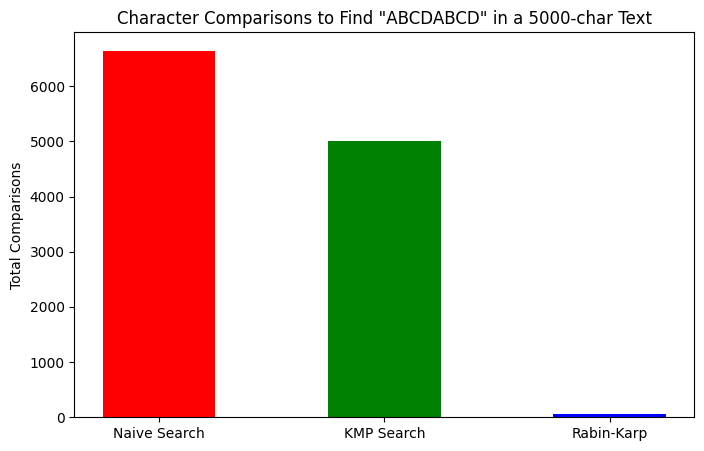

In [ ]:
import random
import matplotlib.pyplot as plt

def naive_search(text, pattern):
    n, m = len(text), len(pattern)
    comparisons = 0
    for i in range(n - m + 1):
        j = 0
        while j < m:
            comparisons += 1
            if text[i + j] != pattern[j]: break
            j += 1
    return comparisons

def compute_lps(pattern):
    m = len(pattern)
    lps = [0] * m
    length, i = 0, 1
    while i < m:
        if pattern[i] == pattern[length]:
            length += 1; lps[i] = length; i += 1
        elif length != 0: length = lps[length - 1]
        else: lps[i] = 0; i += 1
    return lps

def kmp_search(text, pattern):
    n, m = len(text), len(pattern)
    lps = compute_lps(pattern)
    comparisons, i, j = 0, 0, 0
    while i < n:
        comparisons += 1
        if pattern[j] == text[i]: i += 1; j += 1
        if j == m: j = lps[j - 1]
        elif i < n and pattern[j] != text[i]:
            if j != 0: j = lps[j - 1]
            else: i += 1
    return comparisons

def rabin_karp(text, pattern, q=101):
    n, m = len(text), len(pattern)
    d = 256
    h = pow(d, m - 1, q)
    p_hash = t_hash = 0
    comparisons = 0
    for i in range(m):
        p_hash = (d * p_hash + ord(pattern[i])) % q
        t_hash = (d * t_hash + ord(text[i])) % q
    for s in range(n - m + 1):
        if p_hash == t_hash:
            for k in range(m):
                comparisons += 1
                if text[s + k] != pattern[k]: break
        if s < n - m:
            t_hash = (d * (t_hash - ord(text[s]) * h) + ord(text[s + m])) % q
            if t_hash < 0: t_hash += q
    return comparisons


text = ''.join(random.choices('ABCD', k=5000))
pattern = 'ABCDABCD'

naive_comps = naive_search(text, pattern)
kmp_comps = kmp_search(text, pattern)
rk_comps = rabin_karp(text, pattern)


algorithms = ['Naive Search', 'KMP Search', 'Rabin-Karp']
comparison_values = [naive_comps, kmp_comps, rk_comps]

plt.figure(figsize=(8, 5))
plt.bar(algorithms, comparison_values, color=['red', 'green', 'blue'], width=0.5)
plt.title('Character Comparisons to Find "ABCDABCD" in a 5000-char Text')
plt.ylabel('Total Comparisons')
plt.show()

In [ ]:
import heapq

class UnionFind:
    def __init__(self, n):
        self.parent = list(range(n))
    def find(self, x):
        if self.parent[x] != x: 
            self.parent[x] = self.find(self.parent[x])
        return self.parent[x]
    def union(self, x, y):
        rx, ry = self.find(x), self.find(y)
        if rx == ry: return False
        self.parent[ry] = rx
        return True

def kruskal(n, edges):
    edges.sort()
    uf = UnionFind(n)
    mst = []
    cost = 0
    for w, u, v in edges:
        if uf.union(u, v):
            mst.append((u, v, w))
            cost += w
            if len(mst) == n - 1: break
    return mst, cost

def prim(n, adj, start=0):
    INF = float('inf')
    key = [INF] * n
    parent = [-1] * n
    inMST = [False] * n
    key[start] = 0
    pq = [(0, start)]
    mst = []
    cost = 0
    while pq:
        w, u = heapq.heappop(pq)
        if inMST[u]: continue
        inMST[u] = True
        if parent[u] != -1:
            mst.append((parent[u], u, w))
            cost += w
        for v, wt in adj.get(u, []):
            if not inMST[v] and wt < key[v]:
                key[v] = wt
                parent[v] = u
                heapq.heappush(pq, (wt, v))
    return mst, cost


n = 7
edges = [
    (7, 0, 1), (5, 0, 3), (8, 1, 2), (9, 1, 3),
    (7, 1, 4), (5, 2, 4), (15, 3, 4), (6, 3, 5),
    (8, 4, 5), (9, 4, 6), (11, 5, 6)
]
adj = {}
for w, u, v in edges:
    adj.setdefault(u, []).append((v, w))
    adj.setdefault(v, []).append((u, w))


k_mst, k_cost = kruskal(n, edges[:])
p_mst, p_cost = prim(n, adj)

print("=== KRUSKAL'S MST RESULTS ===")
for u, v, w in k_mst:
    print(f"Edge ({u} - {v}) with Weight: {w}")
print(f"Total Cost: {k_cost}\n")

print("=== PRIM'S MST RESULTS ===")
for u, v, w in p_mst:
    print(f"Edge ({u} - {v}) with Weight: {w}")
print(f"Total Cost: {p_cost}")

=== KRUSKAL'S MST RESULTS ===
Edge (0 - 3) with Weight: 5
Edge (2 - 4) with Weight: 5
Edge (3 - 5) with Weight: 6
Edge (0 - 1) with Weight: 7
Edge (1 - 4) with Weight: 7
Edge (4 - 6) with Weight: 9
Total Cost: 39

=== PRIM'S MST RESULTS ===
Edge (0 - 3) with Weight: 5
Edge (3 - 5) with Weight: 6
Edge (0 - 1) with Weight: 7
Edge (1 - 4) with Weight: 7
Edge (4 - 2) with Weight: 5
Edge (4 - 6) with Weight: 9
Total Cost: 39


In [ ]:
import heapq

def dijkstra(graph, source):
    n = len(graph)
    dist = [float('inf')] * n
    prev = [None] * n
    dist[source] = 0
    pq = [(0, source)]
    visited = set()
    
    while pq:
        d, u = heapq.heappop(pq)
        if u in visited: continue
        visited.add(u)
        
        for v, w in graph[u]:
            if dist[u] + w < dist[v]:
                dist[v] = dist[u] + w
                prev[v] = u
                heapq.heappush(pq, (dist[v], v))
    return dist, prev

def reconstruct_path(prev, source, target):
    path = []
    node = target
    while node is not None:
        path.append(node)
        node = prev[node]
    path.reverse()
    return path if path and path[0] == source else []


graph = {
    0: [(1, 4), (2, 1)],
    1: [(3, 1)],
    2: [(1, 2), (3, 5)],
    3: [(4, 3)],
    4: [(5, 2)],
    5: []
}

distances, predecessors = dijkstra(graph, 0)

print("Shortest Paths from Source Vertex 0:")
print("-" * 50)
for v in range(len(graph)):
    path = reconstruct_path(predecessors, 0, v)
    path_str = " -> ".join(map(str, path)) if path else "No Path"
    print(f"Vertex {v} | Distance: {distances[v]} | Path: {path_str}")

Shortest Paths from Source Vertex 0:
--------------------------------------------------
Vertex 0 | Distance: 0 | Path: 0
Vertex 1 | Distance: 3 | Path: 0 -> 2 -> 1
Vertex 2 | Distance: 1 | Path: 0 -> 2
Vertex 3 | Distance: 4 | Path: 0 -> 2 -> 1 -> 3
Vertex 4 | Distance: 7 | Path: 0 -> 2 -> 1 -> 3 -> 4
Vertex 5 | Distance: 9 | Path: 0 -> 2 -> 1 -> 3 -> 4 -> 5


TEST RUN RESULTS
Array: [3, 1, 7, 4, 9, 2, 8, 5, 6, 0]
D&C Results   -> Min: 0, Max: 9, Comparisons: 14
Naive Results -> Min: 0, Max: 9, Comparisons: 18



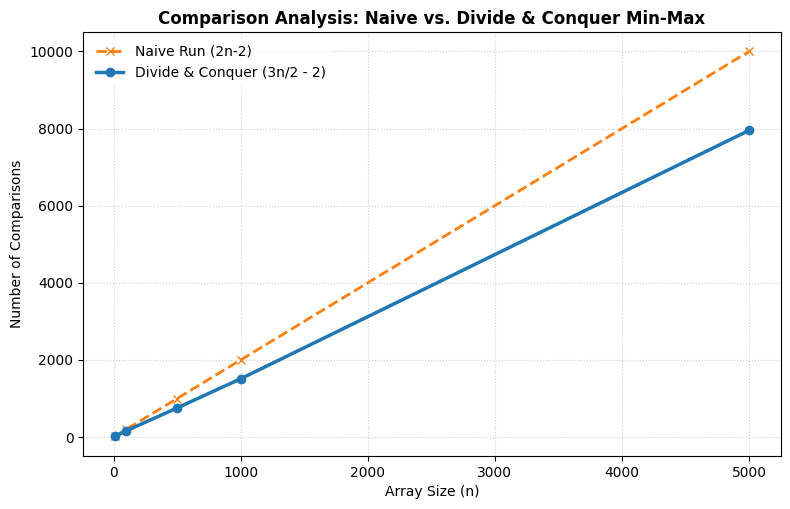

In [ ]:
import random
import matplotlib.pyplot as plt

def min_max_dc(arr, low, high):
    """
    Divide and Conquer Min-Max
    Returns: (min_value, max_value, comparison_count)
    """
    
    if low == high:
        return arr[low], arr[low], 0
    
    
    if high == low + 1:
        if arr[low] < arr[high]:
            return arr[low], arr[high], 1
        else:
            return arr[high], arr[low], 1
            
    
    mid = (low + high) // 2
    
  
    l_min, l_max, l_comps = min_max_dc(arr, low, mid)
    r_min, r_max, r_comps = min_max_dc(arr, mid + 1, high)
    
  
    overall_min = l_min if l_min < r_min else r_min
    overall_max = l_max if l_max > r_max else r_max
    
    total_comps = l_comps + r_comps + 2
    return overall_min, overall_max, total_comps

def min_max_naive(arr):
    """
    Naive Sequential Min-Max
    Returns: (min_value, max_value, comparison_count)
    """
    mn, mx = arr[0], arr[0]
    comps = 0
    for x in arr[1:]:
        comps += 1
        if x < mn:
            mn = x
        comps += 1
        if x > mx:
            mx = x
    return mn, mx, comps


test_arr = [3, 1, 7, 4, 9, 2, 8, 5, 6, 0]
dc_min, dc_max, dc_total_comps = min_max_dc(test_arr, 0, len(test_arr) - 1)
naive_min, naive_max, naive_total_comps = min_max_naive(test_arr)

print("=" * 60)
print("TEST RUN RESULTS")
print("=" * 60)
print(f"Array: {test_arr}")
print(f"D&C Results   -> Min: {dc_min}, Max: {dc_max}, Comparisons: {dc_total_comps}")
print(f"Naive Results -> Min: {naive_min}, Max: {naive_max}, Comparisons: {naive_total_comps}")
print("=" * 60 + "\n")


sizes = [10, 100, 500, 1000, 5000]
dc_results = []
naive_results = []

for size in sizes:
   
    arr = [random.randint(1, 100000) for _ in range(size)]
    
  
    _, _, dc_comps = min_max_dc(arr, 0, len(arr) - 1)
    _, _, naive_comps = min_max_naive(arr)
    
    dc_results.append(dc_comps)
    naive_results.append(naive_comps)


plt.figure(figsize=(9, 5.5))
plt.plot(sizes, naive_results, marker='x', color='#ff7f0e', linestyle='--', linewidth=2, label='Naive Run (2n-2)')
plt.plot(sizes, dc_results, marker='o', color='#1f77b4', linewidth=2.5, label='Divide & Conquer (3n/2 - 2)')

plt.title('Comparison Analysis: Naive vs. Divide & Conquer Min-Max', fontsize=12, fontweight='bold')
plt.xlabel('Array Size (n)', fontsize=10)
plt.ylabel('Number of Comparisons', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(frameon=True, facecolor='white', edgecolor='none')
plt.show()